# 01 - Exploratory Data Analysis
Goal: understand the Telco churn data. No data is modified in this notebook.

In [37]:
# pandas = work with tables, numpy = numbers
import pandas as pd
import numpy as np

# matplotlib and seaborn = charts
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look cleaner
sns.set_style("whitegrid")

# Show all columns when printing a table (default hides some)
pd.set_option("display.max_columns", None)

In [38]:
# ".." means "go one folder up" (from notebooks/ to the project root)
df = pd.read_csv("../data/raw/Telco_Customer_churn.csv")

# Show the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
print("Rows, Columns:", df.shape)

Rows, Columns: (7043, 21)


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [41]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [42]:
#count missing value

print("Missing value per column:")
print(df.isnull().sum())

#count duplicates rows

print("\nDuplicate rows:", df.duplicated().sum())

#Unique customerID for every customer

print("Duplicate customerIDs:", df["customerID"].duplicated().sum())

Missing value per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0
Duplicate customerIDs: 0


In [43]:
#Hidden Problem in TotalCharges to find the problem we create an coerce

total_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")

#How many values could not be converted?
print("Bad TotalCharges values:", total_numeric.isnull().sum())

#No of rows are blank, why they are blank?

df[total_numeric.isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Bad TotalCharges values: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Churn
No     5174
Yes    1869
Name: count, dtype: int64

 Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


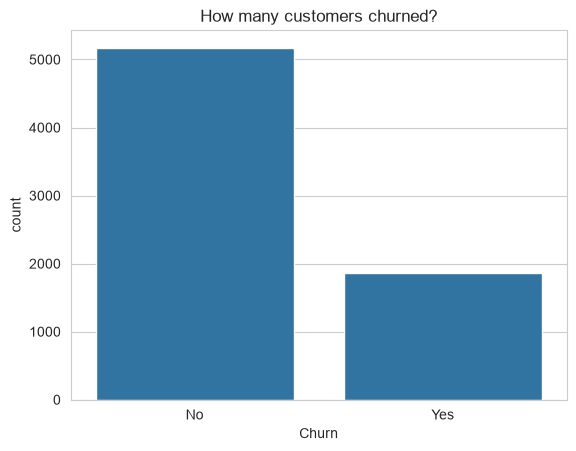

In [44]:
#count customer
print(df["Churn"].value_counts())

#count percentage in customer
print("\n", df["Churn"].value_counts(normalize=True) *100)

#Bar chart
sns.countplot(data=df, x="Churn")
plt.title("How many customers churned?")

# Save the chart to the reports folder
plt.savefig("../reports/figure/churn_balance.png", dpi=150, bbox_inches="tight")
plt.show()

In [45]:
#We generate the version 0/1 so calculate the churn Rates
df["Churn_num"] = (df["Churn"] == "Yes").astype(int)

#Make out the list which store in notebook of above version
df[["Churn", "Churn_num"]].head()

,Churn,Churn_num
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1



Churn rate by Contract:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn_num, dtype: float64

Churn rate by InternetService:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn_num, dtype: float64

Churn rate by PaymentMethod:
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1
Name: Churn_num, dtype: float64

Churn rate by TechSupport:
TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2
Name: Churn_num, dtype: float64


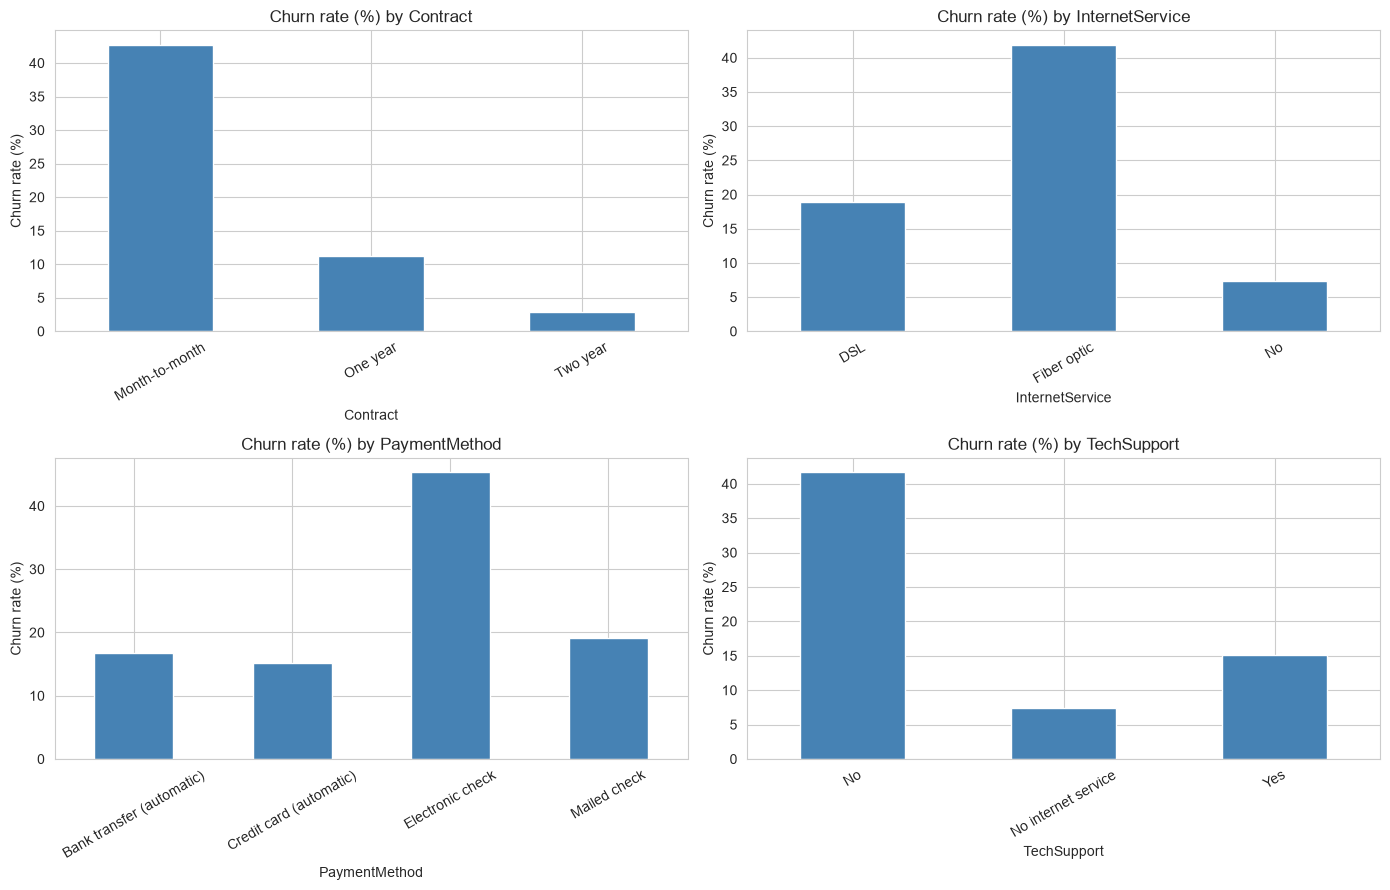

In [46]:
# Columns to study
cat_cols = ["Contract", "InternetService", "PaymentMethod", "TechSupport"]

# Make a 2x2 grid of charts
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Churn rate (%) for each value in this column
    rate = df.groupby(col)["Churn_num"].mean() * 100
    print(f"\nChurn rate by {col}:")
    print(rate.round(1))

    # Draw bar chart
    rate.plot(kind="bar", ax=axes[i], color="steelblue")
    axes[i].set_title(f"Churn rate (%) by {col}")
    axes[i].set_ylabel("Churn rate (%)")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../reports/figure/churn_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

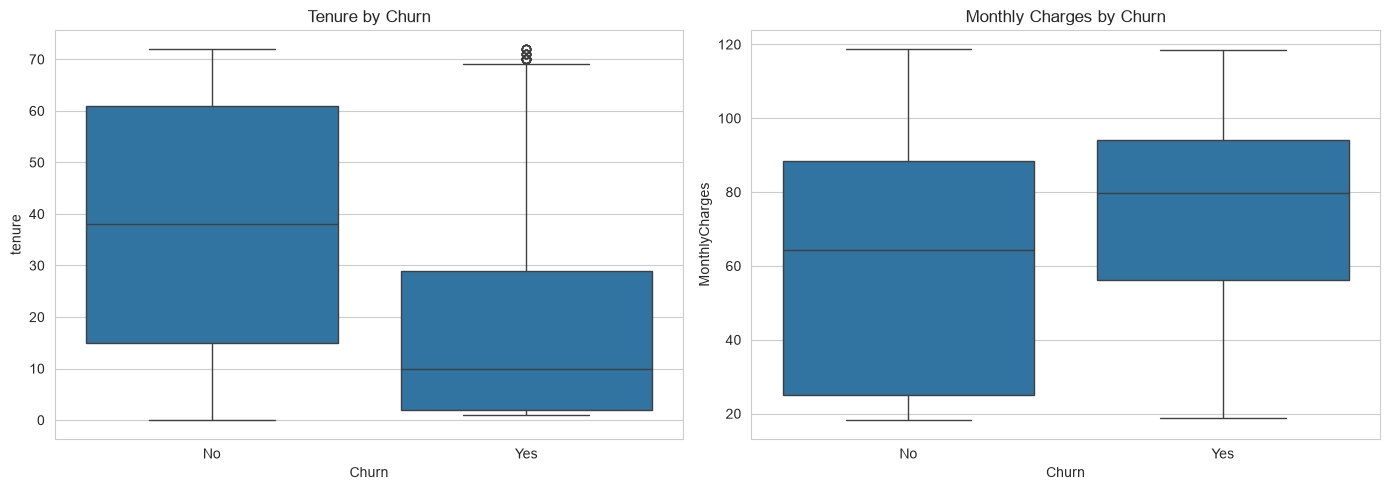

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure (months with the company) for churned vs not churned
sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0])
axes[0].set_title("Tenure by Churn")

# Monthly charges for churned vs not churned
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Monthly Charges by Churn")

plt.tight_layout()
plt.savefig("../reports/figure/churn_numeric.png", dpi=150, bbox_inches="tight")
plt.show()

tenure_group
0-12     47.4
13-24    28.7
25-48    20.4
49-72     9.5
Name: Churn_num, dtype: float64


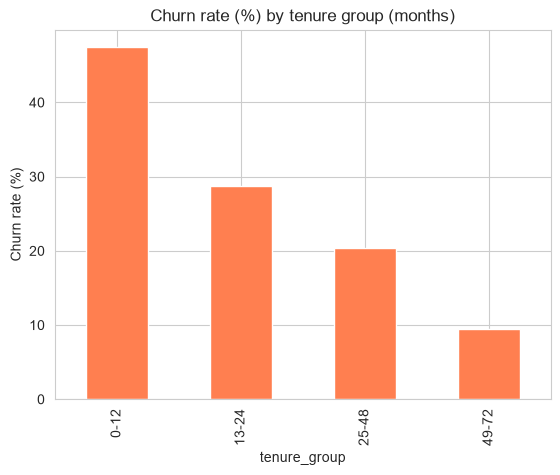

In [48]:
# Cut tenure into groups (bins) to see the pattern clearly
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],                       # group edges
    labels=["0-12", "13-24", "25-48", "49-72"]       # group names (months)
)

# Churn rate for each group
rate = df.groupby("tenure_group", observed=True)["Churn_num"].mean() * 100
print(rate.round(1))

rate.plot(kind="bar", color="coral")
plt.title("Churn rate (%) by tenure group (months)")
plt.ylabel("Churn rate (%)")
plt.savefig("../reports/figure/churn_by_tenure.png", dpi=150, bbox_inches="tight")
plt.show()

## My Findings
1. Dataset has ___ rows and ___ columns. Churn rate is about ___%.
2. Data problem found: TotalCharges is text and has ___ blank values (all with tenure = ___).
3. Contract type: month-to-month customers churn ___% vs two-year ___%.
4. Tenure: customers in the first ___ months are most likely to leave.
5. Other strong signals: ___, ___